Project: Time Series Analysis for Transportation (flights)

Purpose: Robust ingestion, cleaning, validation, in-flight counting, fuel EDA, model selection,
         forecasting with CI, and total fuel spend calculation. Improved plot annotations and layout.

![Baseball Flights](../baseball_flights.png)


To the Office of Transportation at The 22nd Century Sporting League,

After our inaugural 2101 season, The League is looking for ways to optimize our game scheduling process and costs.  We know that transportation logistics are a major variable to consider during scheduling, and as such, we’ve got a few questions for you.

Our primary areas of focus are surrounding the number of jets that The League needs to own, and the cost of fuel for those flights. If we want The League to enjoy continued success, we'll need to make sure we manage transportation costs.

We’re sharing schedule data for the upcoming 2102 season.  On each row, you’ll find information about which teams are needing to travel to their next set of games, the time the flight will likely depart (based on our estimations of gameplay durations) and the time the flight will likely land.

Additionally, we're also providing the fuel price that was paid each day during this past 2101 season. The fuel price fluctuates over time, but we're hoping you'll be able to project it to the future to help with the analysis.

## The Data

### team_flights.csv

| Column     | Description              |
|------------|--------------------------|
| `team_name` | Official team name |
| `departure_datetime` | Date and Time (in UTC) when the flight will depart |
| `landing_datetime` | Date and Time (in UTC) when the flight will land |


### fuel_price.csv

| Column     | Description              |
|------------|--------------------------|
| `date` | Date when the fuel price was recorded |
| `fuel_price` | Corresponding fuel price (in $ per gallon) |


### Important Things to Know
- You can assume that the flight's average speed is 500 MPH. (So, as an example, a 2-hour flight would travel 1000 miles)
- You can assume that each team’s jet fills up with fuel equivalent to 1 gallon per mile-of-travel
- You can assume that the jet is fueled on the day the travel departs (and thus can use the fuel price corresponding to the departure date)

In [1]:
import re
import json
from pathlib import Path
from typing import Tuple, Dict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

# optional auto_arima
try:
    import pmdarima as pm
    PMDARIMA_AVAILABLE = True
except Exception:
    PMDARIMA_AVAILABLE = False


In [2]:
# Configuration for the analysis
RAW_TEAM_FLIGHTS_PATH = "../data/team_flights.csv"
RAW_FUEL_PRICES_PATH = "../data/fuel_prices_2101.csv"
CLEAN_TEAM_FLIGHTS_PATH = "team_flights_clean.csv"
CLEAN_FUEL_PRICES_PATH = "fuel_prices_2101_clean.csv"
RESULTS_JSON = "../results_summary.json"

JET_SPEED_MPH = 500.0
GALLONS_PER_MILE = 1.0
FORECAST_DAYS_2102 = 365

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')  # base style
plt.rcParams.update({
    'figure.dpi': 150,
    'figure.figsize': (12, 4),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'font.family': 'DejaVu Sans'
})

PLOTS_DIR = Path("../plots")
PLOTS_DIR.mkdir(exist_ok=True)

CLEAN_DATA_DIR = Path("../clean_data")
CLEAN_DATA_DIR.mkdir(exist_ok=True)


In [3]:
# Defining functions

# Plot saving function
def save_plot(fig, filename: str):
    out = PLOTS_DIR / filename
    fig.savefig(out, bbox_inches='tight', dpi=300)
    print(f"[save_plot] Saved: {out}")

# Fuel Price column detector
def _find_price_column(df: pd.DataFrame) -> str:
    candidates = ['fuel_price', 'price', 'fuel', 'fuel_price_2101', 'fuelprice']
    for c in candidates:
        if c in df.columns:
            return c
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) == 1:
        return numeric_cols[0]
    for col in df.columns:
        lname = str(col).lower()
        if 'fuel' in lname or 'price' in lname:
            return col
    raise KeyError("Could not detect fuel price column. Columns: " + ", ".join(df.columns))

# Fuel price reading function
def robust_read_fuel_prices(path: str) -> pd.DataFrame:
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"Fuel prices file not found: {path}")
    try:
        df = pd.read_csv(path)
    except Exception:
        df = pd.read_csv(path, header=None)
    date_col = None
    for c in df.columns:
        if str(c).lower() in ('date', 'ds', 'day'):
            date_col = c
            break
    if date_col is None:
        date_col = df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    if df[date_col].isna().any():
        df[date_col] = pd.to_datetime(df[date_col].astype(str).str.strip(), errors='coerce')
    df = df.dropna(subset=[date_col]).reset_index(drop=True)
    price_col = _find_price_column(df)
    df = df[[date_col, price_col]].rename(columns={date_col: 'date', price_col: 'fuel_price'})
    df['fuel_price'] = pd.to_numeric(df['fuel_price'], errors='coerce')
    df = df.dropna(subset=['fuel_price']).reset_index(drop=True)
    df['date'] = pd.to_datetime(df['date']).dt.tz_localize(None)
    df = df.set_index(pd.DatetimeIndex(df['date'])).drop(columns='date')
    df.index.name = 'date'
    df = df.sort_index()
    full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
    if not df.index.equals(full_idx):
        print("[fuel_prices] Reindexing to full daily range and interpolating missing values.")
        df = df.reindex(full_idx)
        df['fuel_price'] = df['fuel_price'].interpolate(method='time').ffill().bfill()
    return df

# Flight data reading function
def robust_read_team_flights(path: str) -> pd.DataFrame:
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"Team flights file not found: {path}")
    text = p.read_text(encoding='utf-8')
    dt_pattern = r'\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}'
    records = []
    for line in text.splitlines():
        datetimes = re.findall(dt_pattern, line)
        if len(datetimes) <= 2:
            records.append(line)
        else:
            parts = re.split(r'(?=\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})', line)
            buffer = ""
            for ppart in parts:
                if not ppart.strip():
                    continue
                if buffer:
                    buffer += ppart
                else:
                    buffer = ppart
                if buffer.count(',') >= 3:
                    records.append(buffer)
                    buffer = ""
            if buffer.strip():
                records.append(buffer)
    parsed = []
    for row in records:
        cols = [c.strip() for c in row.split(',')]
        if len(cols) == 4:
            parsed.append(cols)
        else:
            m = re.match(r'^(.*?),(?P<dep>\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}),(?P<land>\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}),(?P<dist>[-\d\.eE]+)$', row)
            if m:
                parsed.append([m.group(1).strip(), m.group('dep'), m.group('land'), m.group('dist')])
            else:
                parsed.append([None, None, None, None])
    df = pd.DataFrame(parsed, columns=['team_name','departure_datetime','landing_datetime','travel_distance_miles'])
    df['departure_datetime'] = df['departure_datetime'].astype(str).str.strip().replace({'None':'', 'nan':''})
    df['landing_datetime'] = df['landing_datetime'].astype(str).str.strip().replace({'None':'', 'nan':''})
    fmt = "%Y-%m-%d %H:%M:%S"
    dep_parsed = pd.to_datetime(df['departure_datetime'], format=fmt, errors='coerce', utc=True)
    land_parsed = pd.to_datetime(df['landing_datetime'], format=fmt, errors='coerce', utc=True)
    dep_failed = dep_parsed.isna()
    land_failed = land_parsed.isna()
    if dep_failed.any():
        dep_parsed.loc[dep_failed] = pd.to_datetime(df.loc[dep_failed, 'departure_datetime'], errors='coerce', utc=True)
    if land_failed.any():
        land_parsed.loc[land_failed] = pd.to_datetime(df.loc[land_failed, 'landing_datetime'], errors='coerce', utc=True)
    df['departure_datetime'] = dep_parsed
    df['landing_datetime'] = land_parsed
    df['travel_distance_miles'] = pd.to_numeric(df['travel_distance_miles'], errors='coerce')
    before = len(df)
    df = df.dropna(subset=['team_name','departure_datetime','landing_datetime']).reset_index(drop=True)
    after = len(df)
    if before != after:
        print(f"[team_flights] Dropped {before-after} malformed rows during parsing.")
    return df

# Validation & Distance recalculation
def validate_and_recompute_distances(team_df: pd.DataFrame, speed_mph: float = JET_SPEED_MPH) -> Tuple[pd.DataFrame, pd.DataFrame]:
    df = team_df.copy()
    if not pd.api.types.is_datetime64_any_dtype(df['departure_datetime']):
        df['departure_datetime'] = pd.to_datetime(df['departure_datetime'], errors='coerce', utc=True)
    if not pd.api.types.is_datetime64_any_dtype(df['landing_datetime']):
        df['landing_datetime'] = pd.to_datetime(df['landing_datetime'], errors='coerce', utc=True)
    bad_time = df['departure_datetime'].isna() | df['landing_datetime'].isna()
    if bad_time.any():
        nbad = bad_time.sum()
        print(f"[validate] Dropping {nbad} rows with unparseable timestamps.")
        df = df.loc[~bad_time].reset_index(drop=True)
    df['duration_hours'] = (df['landing_datetime'] - df['departure_datetime']).dt.total_seconds() / 3600.0
    df['duration_flag'] = df['duration_hours'] <= 0
    if df['duration_flag'].any():
        print(f"[validate] Found {df['duration_flag'].sum()} rows with non-positive duration; they are flagged.")
    df['computed_distance_miles'] = df['duration_hours'] * float(speed_mph)
    df['distance_diff_pct'] = np.where(df['computed_distance_miles'] > 0,
                                       (df['computed_distance_miles'] - df['travel_distance_miles'].fillna(df['computed_distance_miles'])) / df['computed_distance_miles'],
                                       0.0)
    df['distance_flag'] = False
    df.loc[df['travel_distance_miles'].isna(), 'distance_flag'] = True
    df.loc[df['duration_hours'] <= 0, 'distance_flag'] = True
    df.loc[df['distance_diff_pct'].abs() > 0.02, 'distance_flag'] = True
    corrections = df[df['distance_flag']].copy()
    df.loc[~df['computed_distance_miles'].isna(), 'travel_distance_miles'] = df['computed_distance_miles']
    return df, corrections

# In-flight counting
def compute_in_flight_events(team_df: pd.DataFrame, include_landing_in_flight: bool = False) -> pd.DataFrame:
    if not pd.api.types.is_datetime64_any_dtype(team_df['departure_datetime']) or not pd.api.types.is_datetime64_any_dtype(team_df['landing_datetime']):
        raise TypeError("departure_datetime and landing_datetime must be datetimelike before computing events.")
    dep = team_df[['departure_datetime']].rename(columns={'departure_datetime':'time'}).copy()
    dep['delta'] = 1
    land = team_df[['landing_datetime']].rename(columns={'landing_datetime':'time'}).copy()
    if include_landing_in_flight:
        land['time'] = land['time'] + pd.to_timedelta(1, unit='us')
    land['delta'] = -1
    events = pd.concat([dep, land], axis=0).sort_values('time').reset_index(drop=True)
    events = events.groupby('time', as_index=False)['delta'].sum().sort_values('time').reset_index(drop=True)
    events['in_flight'] = events['delta'].cumsum()
    return events

def get_max_teams_in_flight(events_df: pd.DataFrame) -> Tuple[int, pd.Timestamp]:
    max_val = int(events_df['in_flight'].max())
    max_time = events_df.loc[events_df['in_flight'] == max_val, 'time'].min()
    return max_val, max_time

# Fuel EDA & plotting (saves images)
def fuel_series_eda(fuel_df: pd.DataFrame, show_plots: bool = True) -> Dict:
    if 'fuel_price' not in fuel_df.columns:
        raise KeyError("fuel_df must contain 'fuel_price' column.")
    results = {}
    s = fuel_df['fuel_price'].copy()
    s.index = pd.DatetimeIndex(s.index)
    # Historical series plot
    fig, ax = plt.subplots(figsize=(12,4))
    ax.plot(s.index, s.values, color='#1f77b4', linewidth=1.25)
    ax.set_title('Fuel price (daily) - 2101')
    ax.set_xlabel('Date'); ax.set_ylabel('Price ($/gallon)')
    fig.autofmt_xdate()
    save_plot(fig, "fuel_price_2101_series.png")
    if show_plots:
        plt.show()
    # ADF
    adf_res = adfuller(s.dropna(), autolag='AIC')
    results['adf'] = {'statistic': adf_res[0], 'pvalue': adf_res[1], 'usedlag': adf_res[2], 'nobs': adf_res[3]}
    print(f"[ADF] statistic={adf_res[0]:.4f}, p-value={adf_res[1]:.4f}")
    # STL decomposition and save (improve layout to avoid overlapping suptitle)
    stl = STL(s, period=7, robust=True).fit()
    results['stl'] = stl
    fig2 = stl.plot()
    # Make the figure larger and adjust top margin so the suptitle doesn't overlap the axis labels
    fig2.set_size_inches(12, 6)
    fig2.tight_layout()
    fig2.subplots_adjust(top=0.88)  # leave room for suptitle
    fig2.suptitle('STL Decomposition (period=7)', fontsize=14)
    save_plot(fig2, "fuel_price_2101_stl.png")
    if show_plots:
        plt.show()
    return results

# Modeling & forecast plotting
def select_and_fit_model(series: pd.Series, seasonal_period: int = 7, use_auto_arima: bool = True, train_ratio: float = 0.9):
    s = series.dropna().copy()
    n = len(s)
    split = int(n * train_ratio)
    train = s.iloc[:split]
    test = s.iloc[split:]
    fit_info = {'train_len': len(train), 'test_len': len(test)}
    if use_auto_arima and PMDARIMA_AVAILABLE:
        print("[model] Running pmdarima.auto_arima...")
        auto = pm.auto_arima(train, seasonal=True, m=seasonal_period, stepwise=True, suppress_warnings=True, error_action='ignore', max_p=4, max_q=4, max_P=2, max_Q=2)
        pred_test = auto.predict(n_periods=len(test))
        fit_info['test_rmse'] = float(np.sqrt(np.mean((test.values - pred_test)**2)))
        fit_info['test_mae'] = float(np.mean(np.abs(test.values - pred_test)))
        fc = auto.predict(n_periods=FORECAST_DAYS_2102, return_conf_int=True, alpha=0.05)
        fc_mean = fc[0]; fc_conf = fc[1]
        idx = pd.date_range('2102-01-01', periods=FORECAST_DAYS_2102, freq='D')
        forecast_df = pd.DataFrame({'date': idx, 'price_mean': fc_mean, 'price_lower': fc_conf[:,0], 'price_upper': fc_conf[:,1]}).set_index('date')
        model_obj = auto
    else:
        print("[model] Using SARIMAX fallback.")
        candidates = [((1,1,1),(1,0,0,seasonal_period)), ((2,1,2),(1,0,0,seasonal_period)), ((1,0,1),(1,0,1,seasonal_period))]
        best_res = None; best_aic = np.inf; best_order = None
        for order, sorder in candidates:
            try:
                mod = SARIMAX(train, order=order, seasonal_order=sorder, enforce_stationarity=False, enforce_invertibility=False)
                res = mod.fit(disp=False)
                if res.aic < best_aic:
                    best_aic = res.aic; best_res = res; best_order = (order, sorder)
            except Exception as e:
                print(f"[model] candidate {order}x{sorder} failed: {e}")
        if best_res is None:
            raise RuntimeError("No SARIMAX candidate succeeded.")
        pred = best_res.get_prediction(start=test.index[0], end=test.index[-1])
        pred_mean = pred.predicted_mean
        fit_info['test_rmse'] = float(np.sqrt(np.mean((test.values - pred_mean.values)**2)))
        fit_info['test_mae'] = float(np.mean(np.abs(test.values - pred_mean.values)))
        order, sorder = best_order
        full = SARIMAX(s, order=order, seasonal_order=sorder, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        pred_full = full.get_forecast(steps=FORECAST_DAYS_2102)
        mean = pred_full.predicted_mean
        ci = pred_full.conf_int(alpha=0.05)
        idx = pd.date_range('2102-01-01', periods=FORECAST_DAYS_2102, freq='D')
        forecast_df = pd.DataFrame({'date': idx, 'price_mean': mean.values, 'price_lower': ci.iloc[:,0].values, 'price_upper': ci.iloc[:,1].values}).set_index('date')
        model_obj = full
    return {'model': model_obj, 'forecast': forecast_df, 'train': train, 'test': test, 'fit_info': fit_info}

def plot_forecast_with_ci(series: pd.Series, forecast_df: pd.DataFrame, show_last_n: int = 120):
    fig, ax = plt.subplots(figsize=(12,4))
    cutoff = series.index.max() - pd.Timedelta(days=show_last_n)
    hist = series[series.index >= cutoff]
    ax.plot(hist.index, hist.values, label='Historical (recent)', color='#2b7bba', linewidth=1.25)
    ax.plot(forecast_df.index, forecast_df['price_mean'], label='Forecast 2102', color='#d9534f', linewidth=1.25)
    ax.fill_between(forecast_df.index, forecast_df['price_lower'], forecast_df['price_upper'], color='#d9534f', alpha=0.18)
    ax.set_title('Fuel Price Forecast for 2102')
    ax.set_ylabel('Fuel price ($/gallon)')
    ax.set_xlabel('Date')
    ax.legend()
    fig.autofmt_xdate()
    save_plot(fig, "fuel_price_2102_forecast.png")
    plt.show()

# Cost computation
def compute_total_fuel_spend(team_df: pd.DataFrame, forecast_df: pd.DataFrame) -> Dict:
    df = team_df.copy()
    fc = forecast_df.copy().reset_index().rename(columns={'date':'departure_date'})
    fc['departure_date'] = pd.to_datetime(fc['departure_date']).dt.tz_localize(None)
    df['departure_date'] = pd.to_datetime(df['departure_datetime']).dt.tz_localize(None).dt.floor('D')
    merged = df.merge(fc, on='departure_date', how='left')
    missing = merged['price_mean'].isna().sum()
    if missing > 0:
        raise RuntimeError(f"[compute_cost] {missing} flights have no forecast price after merge. Check forecast horizon.")
    merged['fuel_needed_gallons'] = merged['travel_distance_miles'] * GALLONS_PER_MILE
    if 'price_lower' not in merged.columns or 'price_upper' not in merged.columns:
        merged['price_lower'] = merged['price_mean'] * 0.95
        merged['price_upper'] = merged['price_mean'] * 1.05
    merged['fuel_cost_point'] = merged['fuel_needed_gallons'] * merged['price_mean']
    merged['fuel_cost_lower'] = merged['fuel_needed_gallons'] * merged['price_lower']
    merged['fuel_cost_upper'] = merged['fuel_needed_gallons'] * merged['price_upper']
    total_point = merged['fuel_cost_point'].sum()
    total_lower = merged['fuel_cost_lower'].sum()
    total_upper = merged['fuel_cost_upper'].sum()
    return {'merged_df': merged, 'total_point': float(total_point), 'total_lower': float(total_lower), 'total_upper': float(total_upper)}

# Main Pipeline
def run_full_pipeline(team_path=RAW_TEAM_FLIGHTS_PATH, fuel_path=RAW_FUEL_PRICES_PATH, save_cleaned: bool = True):
    team_raw = robust_read_team_flights(team_path)
    fuel_raw = robust_read_fuel_prices(fuel_path)
    if save_cleaned:
        team_raw.to_csv(CLEAN_DATA_DIR/CLEAN_TEAM_FLIGHTS_PATH, index=False)
        fuel_raw.to_csv(CLEAN_DATA_DIR/CLEAN_FUEL_PRICES_PATH, index=True)
        print(f"[save] Cleaned files -> {CLEAN_DATA_DIR/CLEAN_TEAM_FLIGHTS_PATH}, {CLEAN_DATA_DIR/CLEAN_FUEL_PRICES_PATH}")
    team_validated, corrections = validate_and_recompute_distances(team_raw)
    if len(corrections) > 0:
        corrections.to_csv(CLEAN_DATA_DIR/"distance_corrections.csv", index=False)
        print("[validate] Wrote distance_corrections.csv for inspection.")
    events = compute_in_flight_events(team_validated)
    max_in_flight, max_time = get_max_teams_in_flight(events)
    print(f"[inflight] max_teams_in_flight = {max_in_flight} at {max_time}")
    # Save in-flight step plot (improved annotation placement)
    fig, ax = plt.subplots(figsize=(14,5))
    ax.step(events['time'], events['in_flight'], where='post', color='#1f77b4', linewidth=1.5)
    ax.scatter(events['time'], events['in_flight'], s=18, color='#1f77b4')
    ax.set_title('Number of Teams in Flight (2102 season events)')
    ax.set_xlabel('Date'); ax.set_ylabel('# in flight')
    # Compute annotation placement: place label to left or right depending on space
    x_min, x_max = events['time'].min(), events['time'].max()
    # If peak is in the left half, place label to the right; else place it to the left
    midpoint = x_min + (x_max - x_min) / 2
    if pd.to_datetime(max_time) <= midpoint:
        # place label to right
        text_x = pd.to_datetime(max_time) + (x_max - x_min) * 0.03
        ha = 'left'
    else:
        text_x = pd.to_datetime(max_time) - (x_max - x_min) * 0.03
        ha = 'right'
    text_y = max_in_flight - 0.4
    # Use an arrow pointing to the exact point; offset the text vertically a bit
    ax.annotate(f"Peak = {max_in_flight}",
                xy=(pd.to_datetime(max_time), max_in_flight),
                xytext=(text_x, text_y),
                ha=ha, va='bottom',
                fontsize=11,
                arrowprops=dict(arrowstyle='->', color='black', lw=0.9, shrinkA=0, shrinkB=0),
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='black', lw=0.6, alpha=0.85))
    fig.autofmt_xdate()
    fig.tight_layout()
    save_plot(fig, "teams_in_flight_2102.png")
    plt.show()
    events.to_csv(CLEAN_DATA_DIR/"in_flight_events.csv", index=False)
    # EDA & STL plots
    eda = fuel_series_eda(fuel_raw, show_plots=True)
    # Model selection & forecast
    model_out = select_and_fit_model(fuel_raw['fuel_price'], seasonal_period=7, use_auto_arima=True)
    forecast_df = model_out['forecast']
    plot_forecast_with_ci(fuel_raw['fuel_price'], forecast_df)
    # Compute cost
    cost_out = compute_total_fuel_spend(team_validated, forecast_df)
    print(f"[cost] total_fuel_spend_2102_dollars = {cost_out['total_point']:.2f}")
    print(f"[cost] 95% CI = [{cost_out['total_lower']:.2f}, {cost_out['total_upper']:.2f}]")
    results = {
        'max_teams_in_flight': int(max_in_flight),
        'max_teams_in_flight_time': str(max_time),
        'total_fuel_spend_2102_point': cost_out['total_point'],
        'total_fuel_spend_2102_lower': cost_out['total_lower'],
        'total_fuel_spend_2102_upper': cost_out['total_upper'],
        'model_info': model_out['fit_info']
    }
    Path(RESULTS_JSON).write_text(json.dumps(results, indent=2))
    print(f"[save] Results saved to {RESULTS_JSON}")
    return results


[team_flights] Dropped 1 malformed rows during parsing.
[save] Cleaned files -> ../clean_data/team_flights_clean.csv, ../clean_data/fuel_prices_2101_clean.csv
[inflight] max_teams_in_flight = 19 at 2102-06-26 23:08:00+00:00
[save_plot] Saved: ../plots/teams_in_flight_2102.png


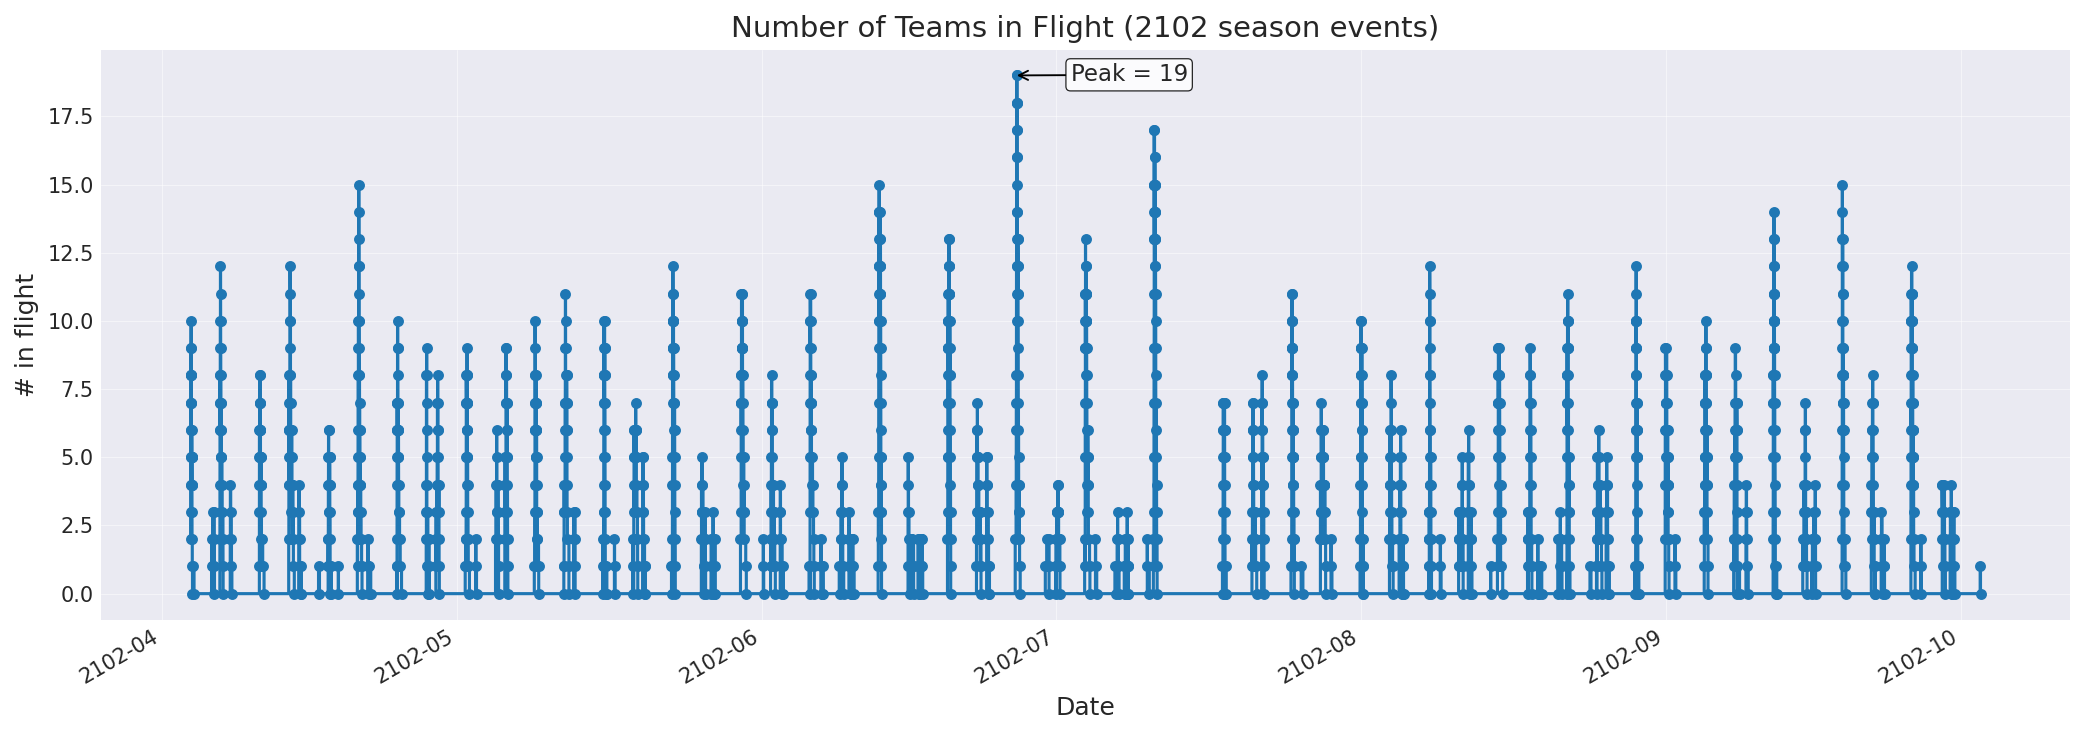

[save_plot] Saved: ../plots/fuel_price_2101_series.png


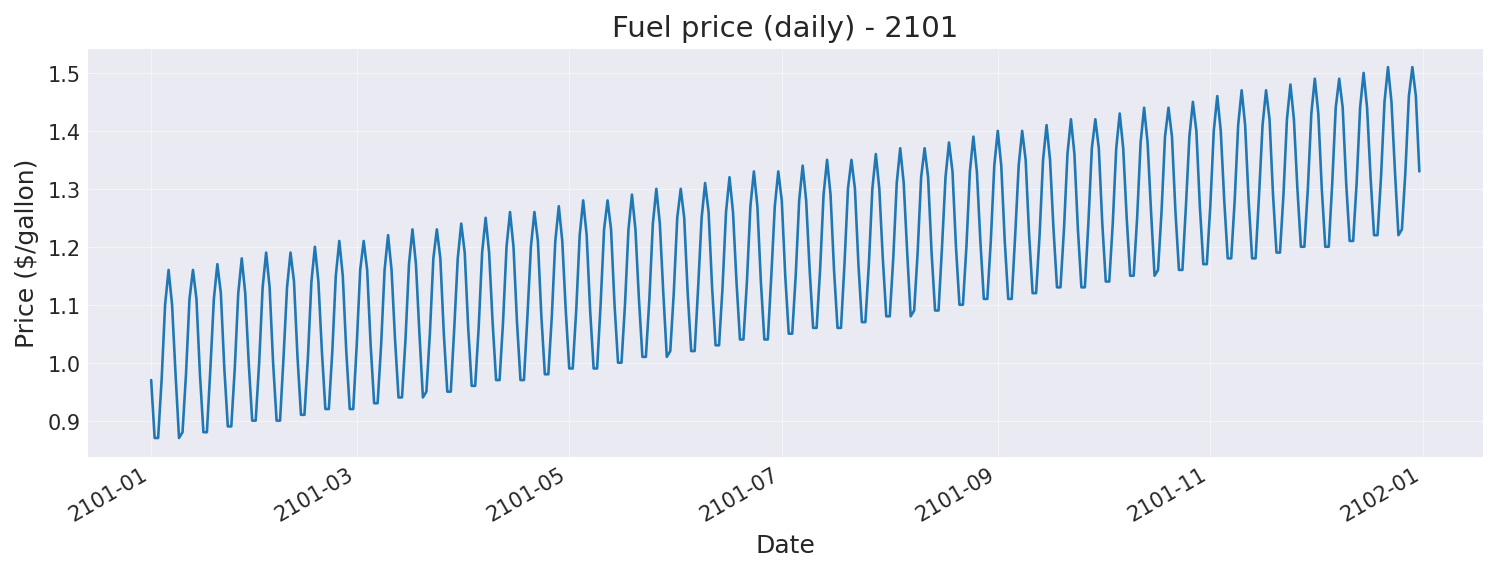

[ADF] statistic=0.1053, p-value=0.9664
[save_plot] Saved: ../plots/fuel_price_2101_stl.png


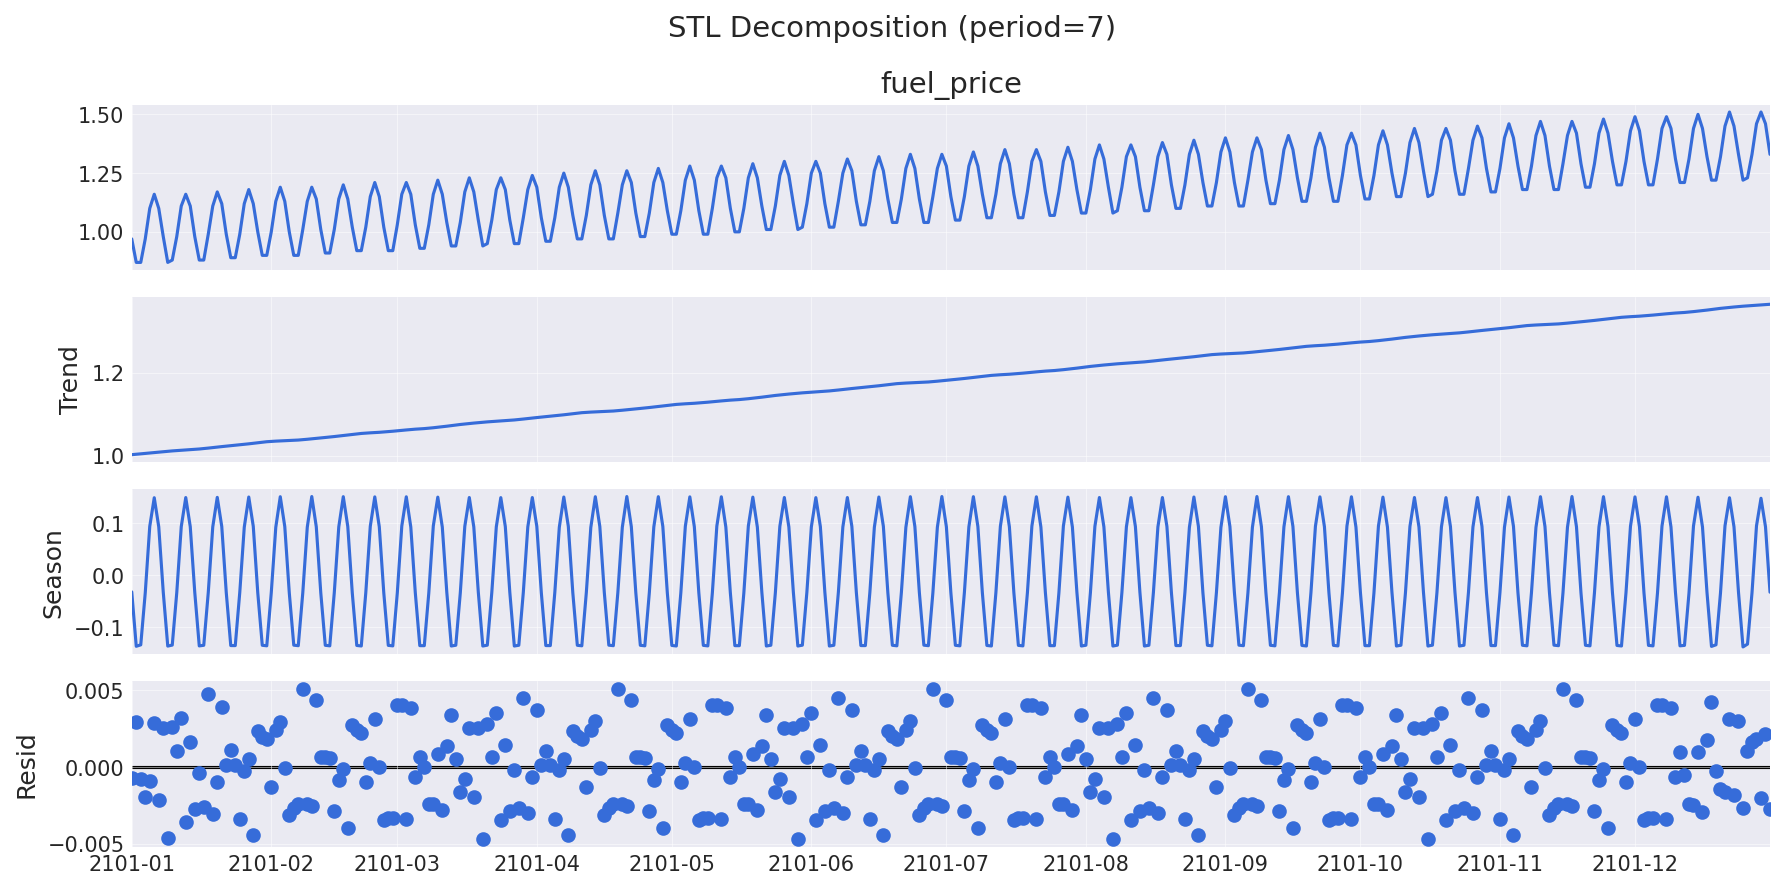

[model] Running pmdarima.auto_arima...
[save_plot] Saved: ../plots/fuel_price_2102_forecast.png


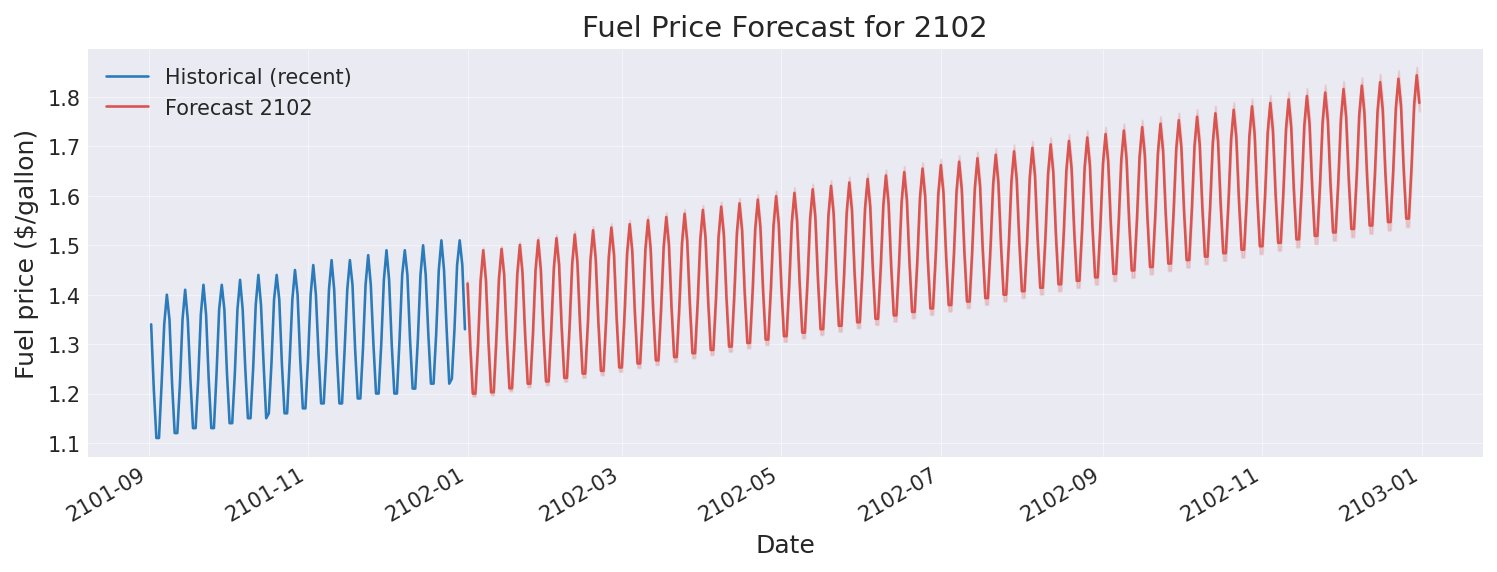

[cost] total_fuel_spend_2102_dollars = 1817003.29
[cost] 95% CI = [1802135.80, 1831870.78]
[save] Results saved to ../results_summary.json


In [4]:
# Running the pipeline
if __name__ == "__main__":
    try:
        res = run_full_pipeline()
    except Exception as e:
        print("[ERROR] Pipeline failed:", str(e))
        raise
